### 학습목표
- 순환신경망 개념을 이해 할 수 있다.
- 바닐라RNN의 단점을 이해하고 개선된 LSTM을 이해 할 수 있다.
- 자연어처리 성능을 높이기 위한 임베딩 기법을 이해 할 수 있다.

In [ ]:
# 작업디렉토리 변경
%cd "/content/drive/MyDrive/Colab Notebooks/26.06.10 자연어처리"

/content/drive/MyDrive/Colab Notebooks/26.06.10 자연어처리


### RNN의 특징
- 이전데이터가 다음데이터에 영향을주는 Sequential한 데이터를 학습시키기 위해 등장 (ex: 문장,음악,주식,날씨 등)
- 입력데이터를 시간순에 따라서 쪼개고 순차적으로 집어 넣는 방식을 채택
- 현재 입력데이터와 직전(과거) 메모리를 합산하는 수식으로 계산

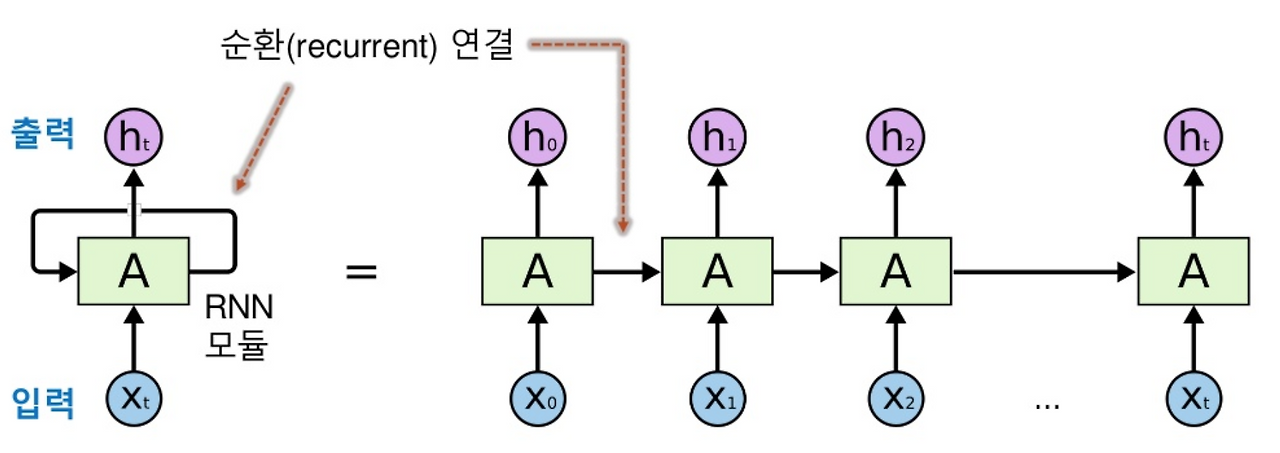

### 네이버영화 리뷰데이터 감성분석
- 네이버영화 리뷰를 수집(평점도 함꼐 수집)
- 리뷰데이터가 긍정/부정인지 판별하는 데이터셋
- https://github.com/e9t/nsmc

#### 감성분석
- 텍스트가 가지고 있는 의도나 감정을 파악하는 분석기법
- 전통적안 감성분석
    - 감성사전을 기반으로 해당단어의 빈도를 측정
- 현재 감성분석
    - 신경망 기반의 학습/추론

In [ ]:
# 데이터로딩
import pandas as pd

In [ ]:
train_df = pd.read_csv('./data/ratings_train.txt', delimiter='\t')
test_df = pd.read_csv('./data/ratings_test.txt', delimiter='\t')

In [ ]:
train_df.dropna(inplace=True)   # 결측치제거
test_df.dropna(inplace=True)    # 결측치제거

In [ ]:
train_df.shape, test_df.shape

((149995, 3), (49997, 3))

In [ ]:
train_df.head()

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


#### 학습을 위한 전처리
- 숫자, 영어, 문장부호 제거
- 형태소분석기 활용 토큰화

In [ ]:
import re

In [ ]:
# !git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git

In [ ]:
# !bash ./Mecab-ko-for-Google-Colab/install_mecab-ko_on_colab_light_220429.sh

In [ ]:
from konlpy.tag import Mecab,Okt,Kkma

In [ ]:
okt = Okt()     # 트위터 기반으로 시작된 형태소 분석기, 비교적 신조어 분리에 강함
mecab = Mecab() # 리눅스기반의 환경에서 동작, 속도가 빠르다
kkma = Kkma()   # Java기반의 분석기, 속도는 느리지만 품사분리가 정교하다

In [ ]:
sample_text = "a123 안녕하세요. 111반갑습니다."
rs = re.sub('[a-z0-9]+', '', sample_text)
rs

' 안녕하세요. 반갑습니다.'

In [ ]:
# 패턴 생성
p = re.compile("[0-9a-zA-Z?!@~.ㅋㅎㅠㅜㅇ]+")

In [ ]:
clean_review = []
for doc in train_df['document'].head(4) :
    temp = []
    for token in doc.split(" ") :
        if not p.search(token) :
            temp.append(token)
    clean_review.append(temp)

In [ ]:
clean_review

[['아', '진짜', '짜증나네요', '목소리'],
 ['가볍지', '않구나'],
 ['너무재밓었다그래서보는것을추천한다'],
 ['교도소', '이야기구먼', '재미는', '조정']]

In [ ]:
# 반복처리 진행상활을 시각화하는 도구
from tqdm import tqdm

In [ ]:
preprocessed_train = []                     # 전처리된 결과물을 담을 리스트
for doc in tqdm(train_df['document']):
    rs = re.sub('[a-zA-Z0-9?!]+', '', doc)  # 정규표현식 전처리
    morphs = mecab.morphs(rs)               # 형태소 단위로 분리
    preprocessed_train.append(' '.join(morphs))

100%|██████████| 149995/149995 [00:09<00:00, 15363.25it/s]


In [ ]:
preprocessed_train

['아 더 빙 . . 진짜 짜증 나 네요 목소리',
 '흠 . .. 포스터 보고 초딩 영화 줄 . ... 오버 연기 조차 가볍 지 않 구나',
 '너무 재 밓었다그래서보는것을추천한다',
 '교도소 이야기 구먼 . . 솔직히 재미 는 없 다 . . 평점 조정',
 '사이몬페그 의 익살 스런 연기 가 돋보였 던 영화 스파이더맨 에서 늙 어 보이 기 만 했 던 커스틴 던스트 가 너무나 도 이뻐 보였 다',
 '막 걸음마 뗀 세 부터 초등 학교 학년 생 인 살용 영화 . ㅋㅋㅋ . .. 별반 개 도 아까움 .',
 '원작 의 긴장감 을 제대로 살려 내 지 못했 다 .',
 '별 반개 도 아깝 다 욕 나온다 이응경 길용우 연기 생활 이 몇 년 인지 . . 정말 발 로 해도 그것 보단 낫 겟 다 납치 . 감금 만 반복 반복 . . 이 드라마 는 가족 도 없 다 연기 못 하 는 사람 만 모엿 네',
 '액션 이 없 는데 도 재미 있 는 몇 안 되 는 영화',
 '왜 케 평점 이 낮 은 건데 꽤 볼 만한데 . . 헐리우드 식 화려 함 에 만 너무 길들여져 있 나',
 '걍인피니트가짱이다 . 진짜 짱 이 다 ♥',
 '볼 때 마다 눈물나 서 죽 겠 다 년 대 의 향수 자극 허진호 는 감성 절제 멜로 의 달인 이 다 ~',
 '울 면서 손들 고 횡단 보도 건널 때 뛰쳐나올 뻔 이범수 연기 드럽 게 못해',
 '담백 하 고 깔끔 해서 좋 다 . 신문 기사 로 만 보다 보 면 자꾸 잊어버린다 . 그 들 도 사람 이 었 다는 것 을 .',
 '취향 은 존중 한다지만 진짜 내생 에 극장 에서 본 영화 중 가장 노 잼 노 감동 임 스토리 도 어 거지 고 감동 도 어거지',
 'ㄱ 냥 매번 긴장 되 고 재 밋 음 ㅠㅠ',
 '참 사람 들 웃긴 게 바스코 가 이기면 락스 코 라고 까 고 바비 가 이기 면 아이돌 이 라고 깐다 . 그냥 까 고 싶 어서 안달 난 것 처럼 보인다',
 '굿바이 레닌 표절 인 것 은 이해 하 는데 왜 뒤 로 갈수록 재미없 어 지 냐',
 '이건 정말 깨알 캐스팅 

In [ ]:
# 테스트데이터 적용하기
preprocessed_test = []                      # 전처리된 결과물을 담을 리스트
for doc in tqdm(test_df['document']):
    rs = re.sub('[a-zA-Z0-9?!]+', '', doc)  # 정규표현식 전처리
    morphs = mecab.morphs(rs)               # 형태소 단위로 분리
    preprocessed_test.append(' '.join(morphs))

100%|██████████| 49997/49997 [00:03<00:00, 15619.56it/s]


#### 토큰화 및 수치화
- https://www.tensorflow.org/api_docs/python/tf/keras/layers/TextVectorization

In [ ]:
from tensorflow.keras.layers import TextVectorization

In [ ]:
vectorizer = TextVectorization(
    max_tokens = 5000,                              # 빈도가 높은 상위 5000개 단어만 사전으로 등록
    output_mode = 'int',                            # 단어사전에 등록된 순번 번호로 수치화
    standardize = "lower_and_strip_punctuation",    # 소문자변환 및 불필요 문장
    output_sequence_length = 10                     # 시퀸스 길이 통일
)

In [ ]:
# 토큰화 및 수치화 실시
# 토큰화 : 띄어쓰기 중심으로 진행
# 수치화 : 단어사전에 등록된 번호로 수치화
vectorizer.adapt(preprocessed_train)    # 훈련데이터기반으로 토큰화, 수치화, 단어사전구축 실시
vectorizer.vocabulary_size()            # 단어사전 크기 확인

5000

In [ ]:
# 등록된 단어토큰 확인
print(vectorizer.get_vocabulary())

['', '[UNK]', np.str_('이'), np.str_('는'), np.str_('영화'), np.str_('다'), np.str_('고'), np.str_('하'), np.str_('도'), np.str_('의'), np.str_('가'), np.str_('은'), np.str_('에'), np.str_('을'), np.str_('한'), np.str_('보'), np.str_('게'), np.str_('들'), np.str_('지'), np.str_('를'), np.str_('있'), np.str_('없'), np.str_('좋'), np.str_('나'), np.str_('었'), np.str_('만'), np.str_('는데'), np.str_('너무'), np.str_('봤'), np.str_('적'), np.str_('안'), np.str_('로'), np.str_('정말'), np.str_('음'), np.str_('으로'), np.str_('것'), np.str_('아'), np.str_('네요'), np.str_('재밌'), np.str_('어'), np.str_('같'), np.str_('지만'), np.str_('진짜'), np.str_('했'), np.str_('기'), np.str_('에서'), np.str_('점'), np.str_('네'), np.str_('않'), np.str_('거'), np.str_('았'), np.str_('수'), np.str_('되'), np.str_('면'), np.str_('ㅋㅋ'), np.str_('과'), np.str_('말'), np.str_('인'), np.str_('연기'), np.str_('잘'), np.str_('최고'), np.str_('주'), np.str_('내'), np.str_('평점'), np.str_('이런'), np.str_('던'), np.str_('어요'), np.str_('와'), np.str_('할'), np.str_('왜'), np.str_('겠'), np.s

In [ ]:
# 학습데이터를 기반으로 정수 시퀸스로 변환
X_train_vec = vectorizer(preprocessed_train)

In [ ]:
X_train_vec[0]

<tf.Tensor: shape=(10,), dtype=int64, numpy=array([ 36,  78, 907,  42, 229,  23,  37, 719,   0,   0])>

In [ ]:
preprocessed_train[0]

'아 더 빙 . . 진짜 짜증 나 네요 목소리'

In [ ]:
# 테스트데이터 변경하기
X_test_vec = vectorizer(preprocessed_test)

In [ ]:
X_train_vec.shape, X_test_vec.shape

(TensorShape([149995, 10]), TensorShape([49997, 10]))

##### RNN 데이터 모양
- (Samples, Time stops, Fratures)
- 마지막 특성을 명시적으로 표현하도록 변환

In [ ]:
import numpy as np

In [ ]:
X_train_vec = np.expand_dims(X_train_vec, -1)
X_test_vec = np.expand_dims(X_test_vec, -1)

In [ ]:
X_train_vec.shape, X_test_vec.shape

((149995, 10, 1), (49997, 10, 1))

#### 학습
- 모델설계(구조 정의)
- 학습방법 설정
- 학습 및 평가

In [ ]:
from tensorflow.keras.models import Sequential  # 모델의 뼈대
from tensorflow.keras.layers import InputLayer  # 입력층
from tensorflow.keras.layers import Dense       # 뉴런의 묶음
from tensorflow.keras.layers import SimpleRNN   # 바닐라 RNN 구현체

In [ ]:
# 뼈대생성
model = Sequential()
# 입력층
model.add(InputLayer(shape=(10, 1)))                # 시퀸스의 길이, 입력 특성 수
# 중간층
model.add(SimpleRNN(units=64))                      # 순환신경망 레이어 추가, 활성화 함수 생략가능
# 출력층
model.add(Dense(units=1, activation='sigmoid'))     # 이진분류(긍정/부정)

In [ ]:
# 모델구조 확인
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_10 (SimpleRNN)       │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 학습방법 설정
model.compile(
    loss = "binary_crossentropy",   # 모델의 손실값 (틀린정도)을 파악하는 도구
    optimizer = "adam",             # 손실값을 기반으로 방향을 알려주는 도구(최적화)
    metrics = ["accuracy"]          # 정확도 평가지표 추가
)

In [ ]:
# 학습 및 평가
simple_his = model.fit(
    X_train_vec,                # 학습용 문제
    train_df['label'],          # 학습용 정답
    epochs = 40,                # 학습횟수
    batch_size = 128,           # 학습시 한 번에 사용하는 샘플수
    validation_split = 0.2      # 검증데이터 분할
)

Epoch 1/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5053 - loss: 0.6964 - val_accuracy: 0.5123 - val_loss: 0.6930
Epoch 2/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5098 - loss: 0.6944 - val_accuracy: 0.5003 - val_loss: 0.6938
Epoch 3/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5111 - loss: 0.6939 - val_accuracy: 0.5159 - val_loss: 0.6935
Epoch 4/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5150 - loss: 0.6934 - val_accuracy: 0.5107 - val_loss: 0.6925
Epoch 5/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5155 - loss: 0.6933 - val_accuracy: 0.5211 - val_loss: 0.6918
Epoch 6/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5168 - loss: 0.6928 - val_accuracy: 0.5033 - val_loss: 0.6949
Epoch 7/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5208 - loss: 0.6921 - val_accuracy: 0.5221 - val_loss: 0.6910
Epoch 8/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5229 - loss: 0.6906 - val_accuracy: 0.

In [ ]:
# 학습결과 시각화
import matplotlib.pyplot as plt

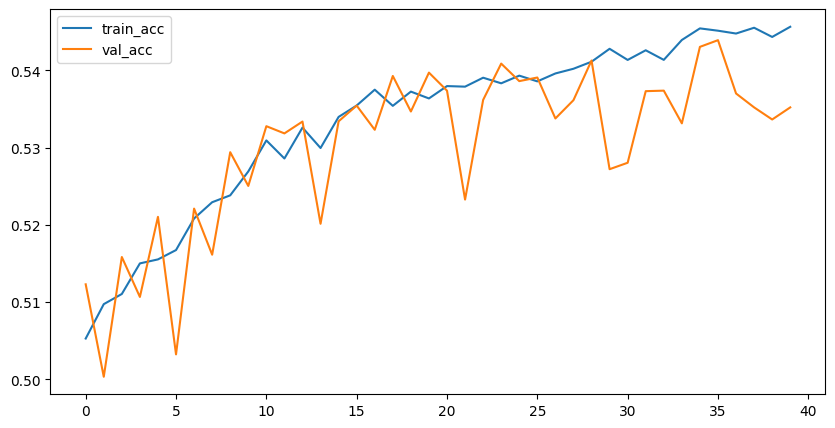

In [ ]:
plt.figure(figsize=(10, 5))  # 가로, 세로 사이즈
plt.plot(simple_his.history['accuracy'], label='train_acc')
plt.plot(simple_his.history['val_accuracy'], label='val_acc')
plt.legend() # 범례
plt.show()

#### SimpleRNN과 현재 토크나이저의 문제점
- SimpleRNN은 시퀸스가 길어질수록 초반 단어에 대한 영향이 약화된다. -> 각 시점에 따라 다른 영향력을 관리한 필요가 있음-
- 현재 토크나이저는 단순 사전숫자로 인코딩된 숫자로 학습하기 때문에 단어가 가진 본질의미를 학습하지 못한다 -> 각 단어의 의미를 정교한 숫자로 변경할 필요가 있음

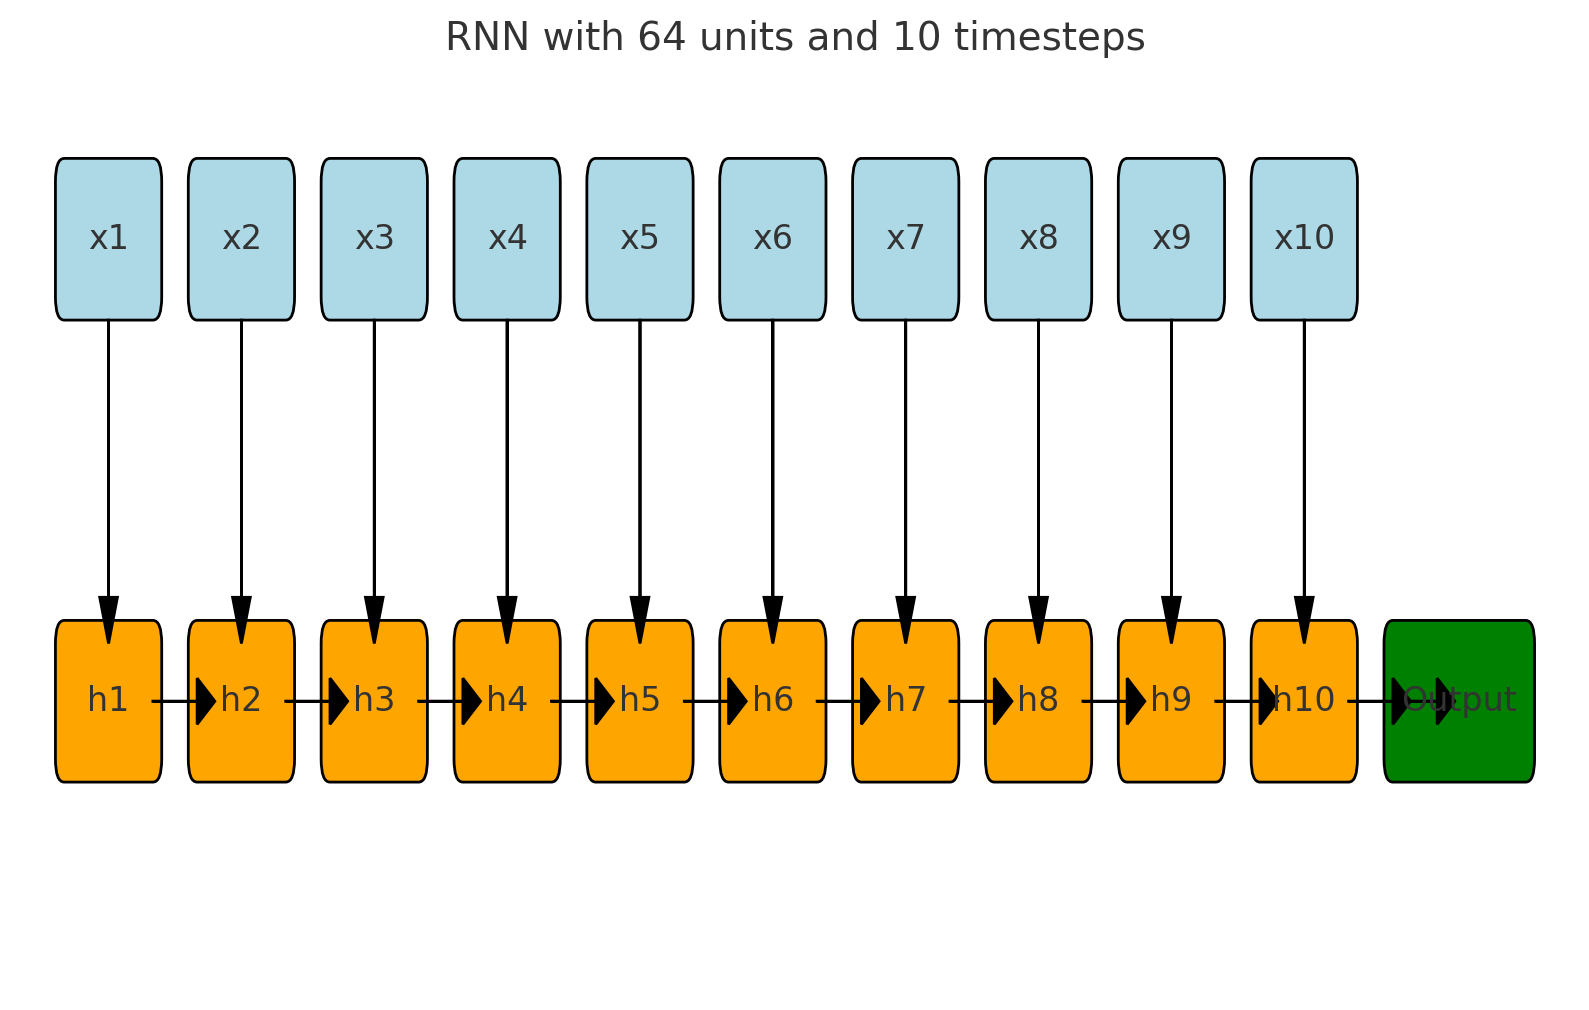

#### LSTM과 GRU
- 장기기억과 단기기억을 관리하는 계산이 추가된 RNN
- LSTM의 연산 복장성을 줄인게 GRU

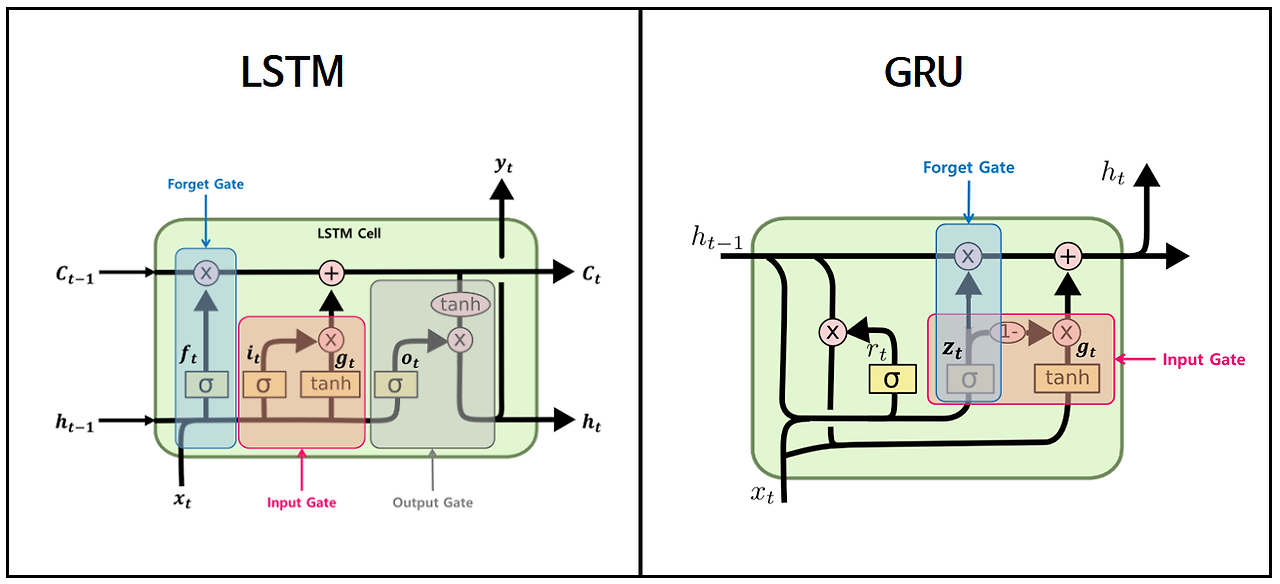

In [ ]:
from tensorflow.keras.layers import LSTM

In [ ]:
# 뼈대생성
model2 = Sequential()
# 입력층
model2.add(InputLayer(shape=(10, 1)))               # 시퀸스의 길이, 입력 특성 수
# 중간층
model2.add(LSTM(units=64))                          # 순환신경망 레이어 추가, 활성화 함수 생략가능
# 출력층
model2.add(Dense(units=1, activation='sigmoid'))    # 이진분류(긍정/부정)

# 학습방법 설정
model2.compile(
    loss = "binary_crossentropy",                   # 모델의 손실값 (틀린정도)을 파악하는 도구
    optimizer = "adam",                             # 손실값을 기반으로 방향을 알려주는 도구(최적화)
    metrics = ["accuracy"]                          # 정확도 평가지표 추가
)

# 학습 및 평가
LSTM_his = model2.fit(
    X_train_vec,                                    # 학습용 문제
    train_df['label'],                              # 학습용 정답
    epochs = 40,                                    # 학습횟수
    batch_size = 128,                               # 학습시 한 번에 사용하는 샘플수
    validation_split = 0.2                          # 검증데이터 분할
)

Epoch 1/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.5346 - loss: 0.6888 - val_accuracy: 0.5351 - val_loss: 0.6873
Epoch 2/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.5457 - loss: 0.6846 - val_accuracy: 0.5443 - val_loss: 0.6834
Epoch 3/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.5520 - loss: 0.6825 - val_accuracy: 0.5477 - val_loss: 0.6830
Epoch 4/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.5539 - loss: 0.6812 - val_accuracy: 0.5512 - val_loss: 0.6811
Epoch 5/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.5585 - loss: 0.6794 - val_accuracy: 0.5499 - val_loss: 0.6802
Epoch 6/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.5611 - loss: 0.6777 - val_accuracy: 0.5619 - val_loss: 0.6769
Epoch 7/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.5643 - loss: 0.6760 - val_accuracy: 0.5611 - val_loss: 0.6763
Epoch 8/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.5667 - loss: 0.6746 - 